In [1]:
import ROOT
from IPython.display import Image, display
import pandas as pd
ROOT.gROOT.SetBatch(True)

root_files = [
    "../../data/00334560_00000001_1.dvntuple.root",
    "../../data/00334560_00000002_1.dvntuple.root",
    "../../data/00334564_00000001_1.dvntuple.root",
    "../../data/00334565_00000001_1.dvntuple.root",
    "../../data/00334566_00000001_1.dvntuple.root",
]
rdf = ROOT.RDataFrame("Btree/DecayTree", root_files)

### Conteo de candidatos

Permíte justificar que tanto se reduce el fondo de cada selección. Además de que indica cuantos candidatos sobreviven a cada corte.

In [2]:
rdf_selec = (
    rdf
    .Filter("J_psi_1S_M > 3050 && J_psi_1S_M < 3150", "Ventana de masa J/psi")
    .Filter("Bplus_M > 5150 && Bplus_M < 5400", "Ventana de masa B")
)

report = rdf_selec.Report()
report.Print()

Ventana de masa J/psi: pass=5191777    all=5428778    -- eff=95.63 % cumulative eff=95.63 %
Ventana de masa B: pass=2583536    all=5191777    -- eff=49.76 % cumulative eff=47.59 %


### Comparación de masa $B$ antes y despues de corte en $J/\psi$

Se busca seleccionar candidatos compatibles con $J/\psi$, la distribución de masa del $B$ se debería de volver más limpia.

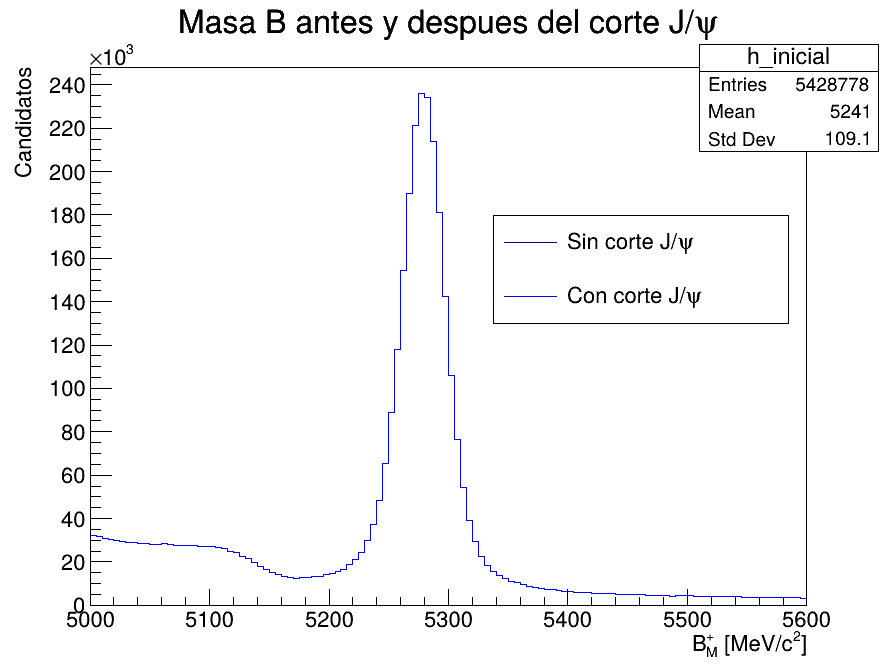

Info in <TCanvas::Print>: png file figs/p02_bmasa_vs_jpsi.png has been created


In [ ]:
rdf_jpsi = rdf.Filter("J_psi_1S_M > 3050 && J_psi_1S_M < 3150")
h_inicial = rdf.Histo1D(
    ("h_inicial", "Masa B antes y despues del corte J/#psi;B^{+}_{M} [MeV/c^{2}];Candidatos", 120, 5000, 5600),
    "Bplus_M"
)
h_final = rdf.Histo1D(
    ("h_final", "Masa B antes y despues del corte J/#psi;B^{+}_{M} [MeV/c^{2}];Candidatos", 120, 5000, 5600),
    "Bplus_M"
)
canvas = ROOT.TCanvas("c_comparacion", "", 900, 700)

h_inicial.SetLineColor(ROOT.kRed)
h_inicial.SetLineWidth(1)

h_final.SetLineColor(ROOT.kBlue)
h_final.SetLineWidth(1)

h_inicial.Draw("HIST")
h_final.Draw("HIST SAME")

legend = ROOT.TLegend(0.55, 0.52, 0.88, 0.68)
legend.SetTextSize(0.035)
# legend.SetBorderSize(0)
# legend.SetFillStyle(0)
legend.AddEntry(h_inicial.GetPtr(), "Sin corte J/#psi", "l")
legend.AddEntry(h_final.GetPtr(), "Con corte J/#psi", "l")
legend.Draw()

canvas.SaveAs("figs/p02_bmasa_vs_jpsi.png")
display(Image("figs/p02_bmasa_vs_jpsi.png"))

### Ajuste del pico de masa del $B$

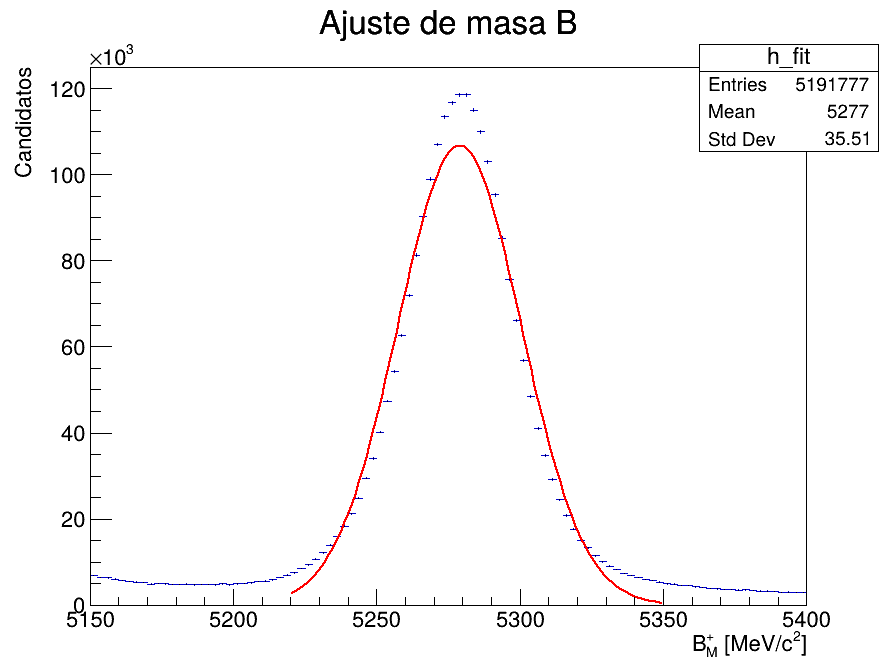

Media del pico B: 5279.035352281154
$\sigma$: 21.600515927742244
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      55083.8
NDf                       =           49
Edm                       =  1.93932e-09
NCalls                    =           76
Constant                  =       106651   +/-   97.4709     
Mean                      =      5279.04   +/-   0.0144737   
Sigma                     =      21.6005   +/-   0.0141245    	 (limited)


Info in <TCanvas::Print>: png file figs/p02_fit_bmass.png has been created


In [4]:
rdf_jpsi = rdf.Filter("J_psi_1S_M > 3050 && J_psi_1S_M < 3150")
h_fit = rdf_jpsi.Histo1D(
    ("h_fit", "Ajuste de masa B;B^{+}_{M} [MeV/c^{2}];Candidatos", 100, 5150, 5400),
    "Bplus_M"
)
canvas = ROOT.TCanvas("c_fit", "", 900, 700)
h_fit.SetLineColor(ROOT.kBlue + 1)
h_fit.SetLineWidth(1)
h_fit.Draw("E")

fit_result = h_fit.Fit("gaus", "S", "", 5220, 5350)

canvas.SaveAs("figs/p02_fit_bmass.png")
display(Image("figs/p02_fit_bmass.png"))

gaus = h_fit.GetFunction("gaus")
print("Media del pico B:", gaus.GetParameter(1))
print("$\sigma$:", gaus.GetParameter(2))

## Señal de fondo

Se divide la masa del $B$ en zonas
* Sideband izquierda: fondo antes del pico
* Región señal: zona alrededor del pico del $B$
* Sideband derecha: fondo después del pico

In [5]:
signal = rdf_jpsi.Filter("Bplus_M > 5240 && Bplus_M < 5320")
left_sideband = rdf_jpsi.Filter("Bplus_M > 5100 && Bplus_M < 5200")
right_sideband = rdf_jpsi.Filter("Bplus_M > 5400 && Bplus_M < 5500")

n_signal = signal.Count().GetValue()
n_left = left_sideband.Count().GetValue()
n_right = right_sideband.Count().GetValue()

print("Candidatos en región de señal:", n_signal)
print("Candidatos en sideband izquierda:", n_left)
print("Candidatos en sideband derecha:", n_right)
print("Fondo aproximado promedio:", (n_left+n_right)/2)

Candidatos en región de señal: 2154493
Candidatos en sideband izquierda: 321998
Candidatos en sideband derecha: 93369
Fondo aproximado promedio: 207683.5


### Distribuciones de momentum y momentum transversal

Determinando columnas disponibles

In [6]:
columns = sorted([str(c) for c in rdf.GetColumnNames()])
for col in columns:
    if "_PT" in col or "_P" in col or "_ETA" in col or "_PHI" in col:
        print(col)

Bplus_P
Bplus_PE
Bplus_PT
Bplus_PX
Bplus_PY
Bplus_PZ
J_psi_1S_P
J_psi_1S_PE
J_psi_1S_PT
J_psi_1S_PX
J_psi_1S_PY
J_psi_1S_PZ
Kplus_MC12TuneV2_ProbNNe
Kplus_MC12TuneV2_ProbNNghost
Kplus_MC12TuneV2_ProbNNk
Kplus_MC12TuneV2_ProbNNmu
Kplus_MC12TuneV2_ProbNNp
Kplus_MC12TuneV2_ProbNNpi
Kplus_MC12TuneV3_ProbNNe
Kplus_MC12TuneV3_ProbNNghost
Kplus_MC12TuneV3_ProbNNk
Kplus_MC12TuneV3_ProbNNmu
Kplus_MC12TuneV3_ProbNNp
Kplus_MC12TuneV3_ProbNNpi
Kplus_MC12TuneV4_ProbNNe
Kplus_MC12TuneV4_ProbNNghost
Kplus_MC12TuneV4_ProbNNk
Kplus_MC12TuneV4_ProbNNmu
Kplus_MC12TuneV4_ProbNNp
Kplus_MC12TuneV4_ProbNNpi
Kplus_MC15TuneV1_ProbNNe
Kplus_MC15TuneV1_ProbNNghost
Kplus_MC15TuneV1_ProbNNk
Kplus_MC15TuneV1_ProbNNmu
Kplus_MC15TuneV1_ProbNNp
Kplus_MC15TuneV1_ProbNNpi
Kplus_P
Kplus_PE
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
Kplus_PT
Kplus_PX
Kplus_PY
Kplus_PZ
Kplus_ProbNNd
Kplus_ProbNNe
Kplus_ProbNNghost
Kplus_ProbNNk
Kplus_ProbNNmu
Kplus_ProbNNp
Kplus_ProbNNpi
muminus_MC12TuneV2_ProbNNe
muminus_MC12

Gráfica de momentum transversal

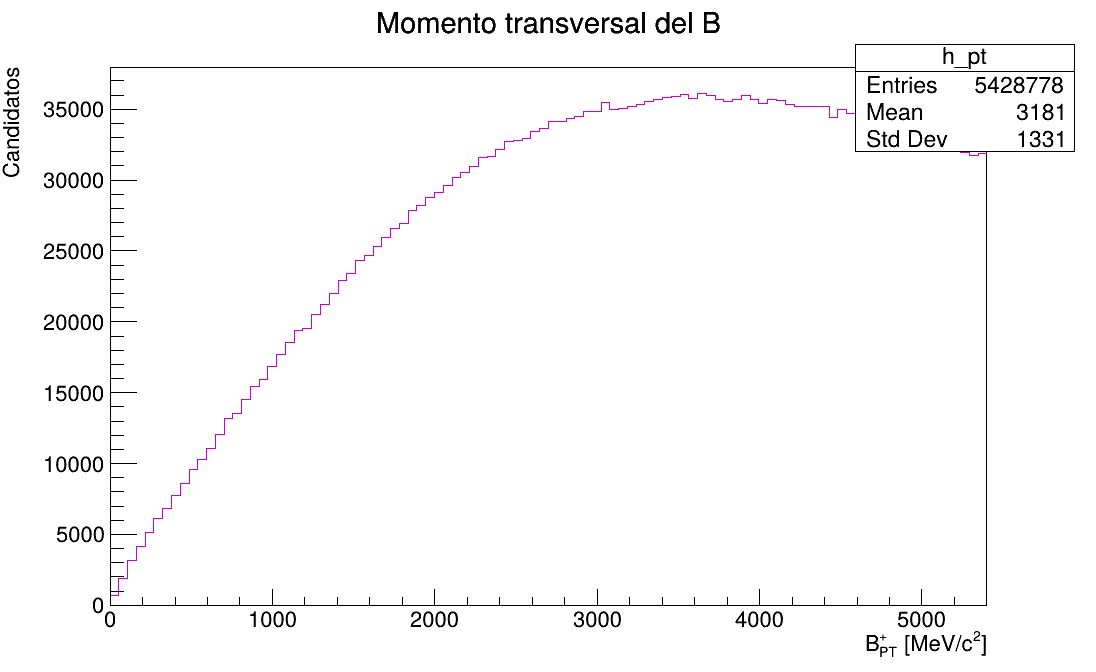

Info in <TCanvas::Print>: png file figs/p02_bplus_pt.png has been created


In [7]:
h_pt = rdf.Histo1D(
    ("h_pt", "Momento transversal del B;B^{+}_{PT} [MeV/c^{2}];Candidatos", 100, 0, 5400),
    "Bplus_PT"
)
canvas =  ROOT.TCanvas("c_pt", "", 1100, 700)

h_pt.SetLineColor(ROOT.kMagenta+1)
h_pt.SetLineWidth(1)
h_pt.Draw("HIST")

canvas.SaveAs("figs/p02_bplus_pt.png")
display(Image("figs/p02_bplus_pt.png"))

Análisis de `Bplus_PT`, `Kplus_PT`, `muplus_PT`, `mumiplus_PT`, `B_plus_P`, `Kplus_P`, `muplus_P`, `mumiplus_P`.

## Relación entre masa y momento transversal

Buscando un candidato con mayor momento transversal `PT` para determinar si tienen una masa reconstruida más limpia.

In [8]:
h2d_pt_mass = rdf.Histo2D(
    (
        "h2d_pt_mass", 
        "Masa B vs PT del B;B^{+}_{PT} [MeV/c];B^{+}_{M} [MeV/c^{2}]",
        100, 0, 50000,
        100, 5000, 5600
    ),
    "Bplus_PT",
    "Bplus_M"
)

canvas = ROOT.TCanvas("c_pt_mass", "", 1000, 700)
ROOT.gStyle.SetOptStat(0)
canvas.SetLogz()

h2d_pt_mass.Draw("COLZ")
canvas.SaveAs("figs/p02_bmass_vs_pt.png")
# display(Image("figs/p02_bmass_vs_pt.png"))

Info in <TCanvas::Print>: png file figs/p02_bmass_vs_pt.png has been created


### Calidad del Vértice

Buscando columnas relacionadas con la calidad del vértice

In [9]:
for col in columns:
    if "CHI2" in col or "VERTEX" in col or "FD" in col or "IP" in col:
        print(col)

Bplus_ENDVERTEX_CHI2
Bplus_ENDVERTEX_COV_
Bplus_ENDVERTEX_NDOF
Bplus_ENDVERTEX_X
Bplus_ENDVERTEX_XERR
Bplus_ENDVERTEX_Y
Bplus_ENDVERTEX_YERR
Bplus_ENDVERTEX_Z
Bplus_ENDVERTEX_ZERR
Bplus_FDCHI2_OWNPV
Bplus_FD_OWNPV
Bplus_IPCHI2_OWNPV
Bplus_IP_OWNPV
Bplus_OWNPV_CHI2
J_psi_1S_ENDVERTEX_CHI2
J_psi_1S_ENDVERTEX_COV_
J_psi_1S_ENDVERTEX_NDOF
J_psi_1S_ENDVERTEX_X
J_psi_1S_ENDVERTEX_XERR
J_psi_1S_ENDVERTEX_Y
J_psi_1S_ENDVERTEX_YERR
J_psi_1S_ENDVERTEX_Z
J_psi_1S_ENDVERTEX_ZERR
J_psi_1S_FDCHI2_ORIVX
J_psi_1S_FDCHI2_OWNPV
J_psi_1S_FD_ORIVX
J_psi_1S_FD_OWNPV
J_psi_1S_IPCHI2_OWNPV
J_psi_1S_IP_OWNPV
J_psi_1S_ORIVX_CHI2
J_psi_1S_OWNPV_CHI2
Kplus_IPCHI2_OWNPV
Kplus_IP_OWNPV
Kplus_ORIVX_CHI2
Kplus_OWNPV_CHI2
muminus_IPCHI2_OWNPV
muminus_IP_OWNPV
muminus_ORIVX_CHI2
muminus_OWNPV_CHI2
muplus_IPCHI2_OWNPV
muplus_IP_OWNPV
muplus_ORIVX_CHI2
muplus_OWNPV_CHI2


Utilizando la columna `Bplus_ENDVERTEX_CHI2`

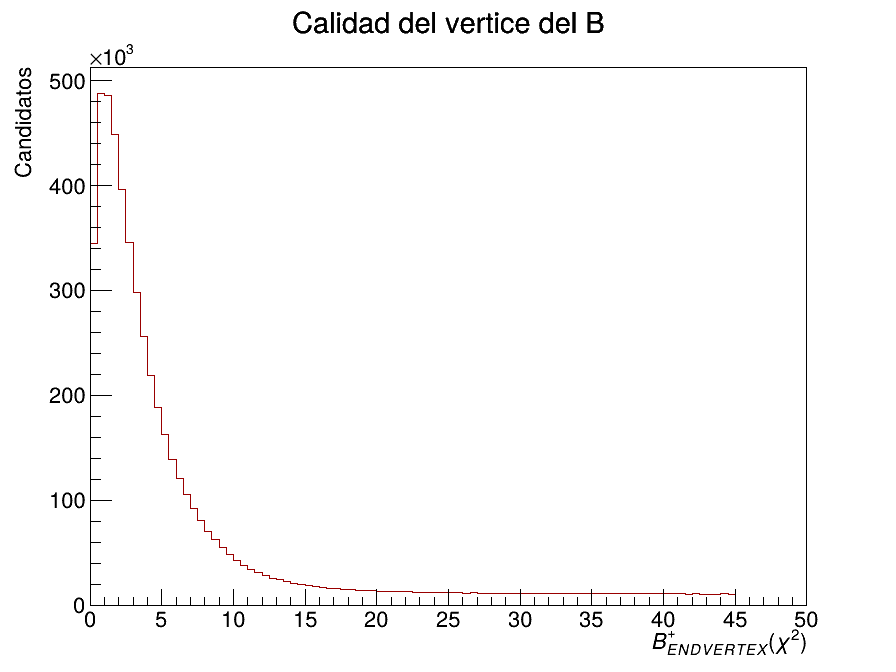

Info in <TCanvas::Print>: png file figs/p02_vertex_chi2_B.png has been created


In [10]:
h_vtx = rdf.Histo1D(
    ("h_vtx", "Calidad del vertice del B;B^{+}_{ENDVERTEX}(\chi^{2});Candidatos", 100, 0, 50),
    "Bplus_ENDVERTEX_CHI2"
)
canvas = ROOT.TCanvas("c_vtx", "", 900, 700)
h_vtx.SetLineColor(ROOT.kRed+2)
h_vtx.SetLineWidth(1)
h_vtx.Draw("HIST")

canvas.SaveAs("figs/p02_vertex_chi2_B.png")
display(Image("figs/p02_vertex_chi2_B.png"))

Aplicación de corte al vértice `Bplus_ENDVERTEX_CHI2`

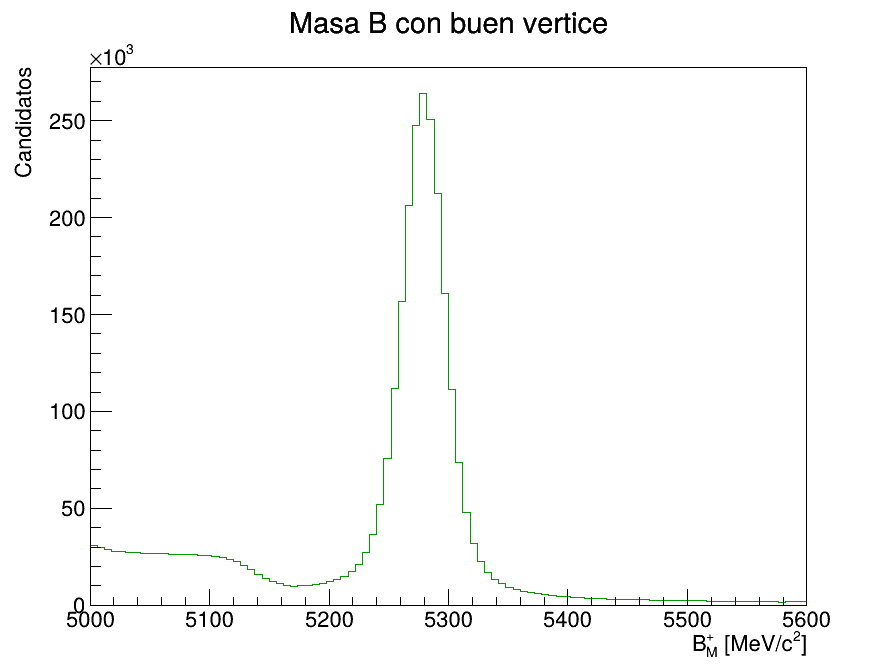

Info in <TCanvas::Print>: png file figs/p02_vertex_chi2_B_corte.png has been created


In [11]:
# Aplicación de Corte
rdf_g_vertex = rdf.Filter("Bplus_ENDVERTEX_CHI2 < 10")

h_g = rdf_g_vertex.Histo1D(
    ("h_g", "Masa B con buen vertice;B^{+}_{M} [MeV/c^{2}];Candidatos", 100, 5000, 5600),
    "Bplus_M"
)

canvas = ROOT.TCanvas("c_g", "", 900, 700)
h_g.SetLineColor(ROOT.kGreen+2)
h_g.SetLineWidth(1)
h_g.Draw("HIST")

canvas.SaveAs("figs/p02_vertex_chi2_B_corte.png")
display(Image("figs/p02_vertex_chi2_B_corte.png"))

## Partículas PID

La identificación de partículas PID se utiliza para diferenciar cones, piones, muones. Buscando las columnas

In [12]:
for col in columns:
    if "PID" in col or "ProbNN" in col or "DLL" in col:
        print(col)

Kplus_MC12TuneV2_ProbNNe
Kplus_MC12TuneV2_ProbNNghost
Kplus_MC12TuneV2_ProbNNk
Kplus_MC12TuneV2_ProbNNmu
Kplus_MC12TuneV2_ProbNNp
Kplus_MC12TuneV2_ProbNNpi
Kplus_MC12TuneV3_ProbNNe
Kplus_MC12TuneV3_ProbNNghost
Kplus_MC12TuneV3_ProbNNk
Kplus_MC12TuneV3_ProbNNmu
Kplus_MC12TuneV3_ProbNNp
Kplus_MC12TuneV3_ProbNNpi
Kplus_MC12TuneV4_ProbNNe
Kplus_MC12TuneV4_ProbNNghost
Kplus_MC12TuneV4_ProbNNk
Kplus_MC12TuneV4_ProbNNmu
Kplus_MC12TuneV4_ProbNNp
Kplus_MC12TuneV4_ProbNNpi
Kplus_MC15TuneV1_ProbNNe
Kplus_MC15TuneV1_ProbNNghost
Kplus_MC15TuneV1_ProbNNk
Kplus_MC15TuneV1_ProbNNmu
Kplus_MC15TuneV1_ProbNNp
Kplus_MC15TuneV1_ProbNNpi
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
Kplus_ProbNNd
Kplus_ProbNNe
Kplus_ProbNNghost
Kplus_ProbNNk
Kplus_ProbNNmu
Kplus_ProbNNp
Kplus_ProbNNpi
muminus_MC12TuneV2_ProbNNe
muminus_MC12TuneV2_ProbNNghost
muminus_MC12TuneV2_ProbNNk
muminus_MC12TuneV2_ProbNNmu
muminus_MC12TuneV2_ProbNNp
muminus_MC12TuneV2_ProbNNpi
muminus_MC12TuneV3_ProbNNe
muminus_MC12TuneV3_Pr

Para kaones `Kplus_PIDK`

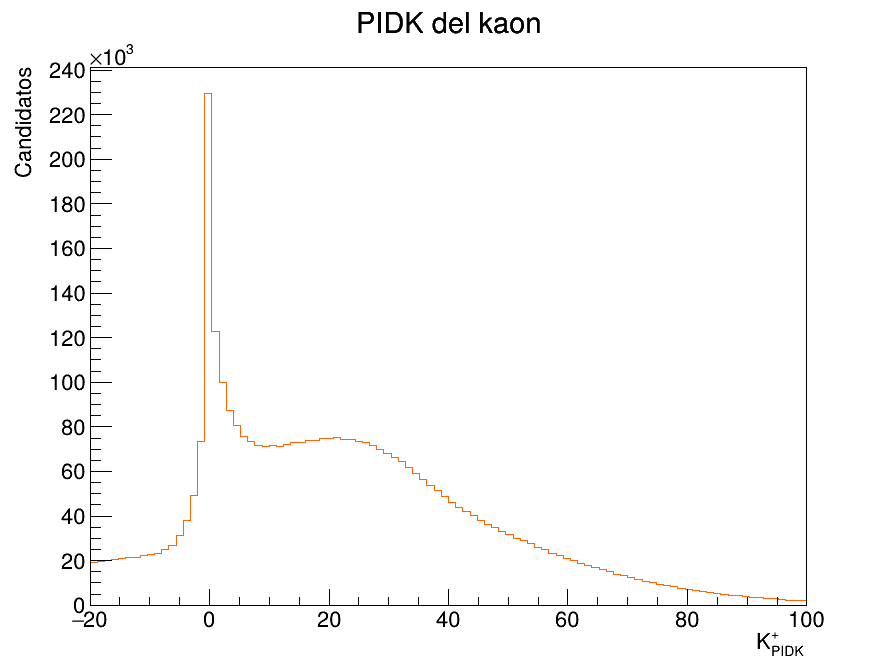

Info in <TCanvas::Print>: png file figs/p02_kplus_pidk.png has been created


In [13]:
h_pidk = rdf_g_vertex.Histo1D(
    ("h_pidk", "PIDK del kaon;K^{+}_{PIDK};Candidatos", 100, -20, 100),
    "Kplus_PIDK"
)

canvas = ROOT.TCanvas("c_pidk", "", 900, 700)
h_pidk.SetLineColor(ROOT.kOrange+7)
h_pidk.SetLineWidth(1)
h_pidk.Draw("HIST")

canvas.SaveAs("figs/p02_kplus_pidk.png")
display(Image("figs/p02_kplus_pidk.png"))

Aplicando corte

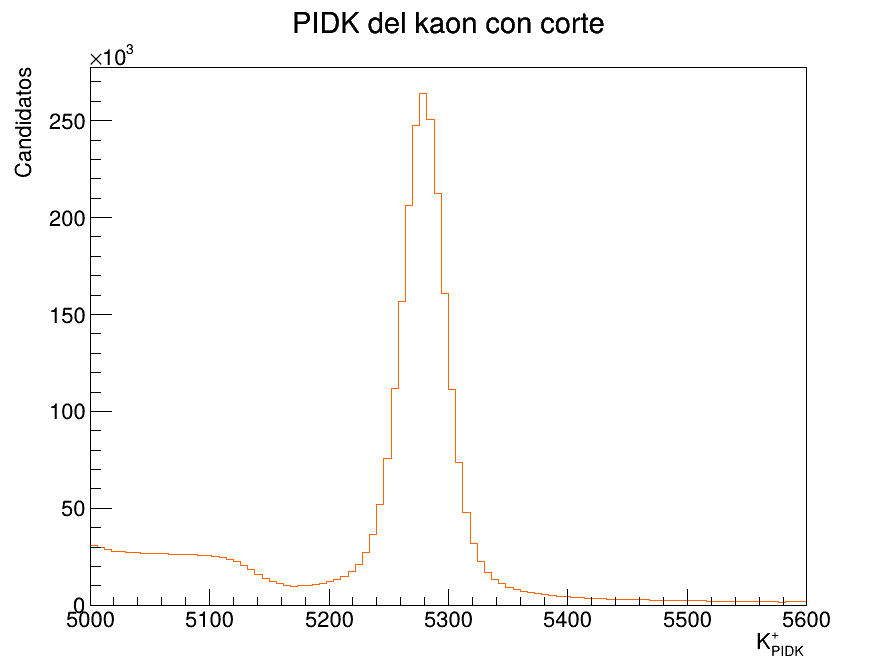

Info in <TCanvas::Print>: png file figs/p02_kplus_g_pidk.png has been created


In [14]:
# Aplicación de Corte
rdf_g_pid = rdf.Filter("Kplus_PIDK > 0")

h_g_pid = rdf_g_vertex.Histo1D(
    ("h_g_pid", "PIDK del kaon con corte;K^{+}_{PIDK};Candidatos", 100, 5000, 5600),
    "Bplus_M"
)

canvas = ROOT.TCanvas("c_g_pid", "", 900, 700)
h_g_pid.SetLineColor(ROOT.kOrange+7)
h_g_pid.SetLineWidth(1)
h_g_pid.Draw("HIST")

canvas.SaveAs("figs/p02_kplus_g_pidk.png")
display(Image("figs/p02_kplus_g_pidk.png"))

## Conversión a NumPy/Pandas

Convirtiendo columnas de ntuple a NumPy

In [15]:
data = rdf.AsNumpy(["Bplus_M", "J_psi_1S_M"])

print(data["Bplus_M"][:10])
print(data["J_psi_1S_M"][:10])

[4956.72956696 5156.59519451 5254.09230981 5224.64008329 5312.55512913
 4792.2197362  5102.87448405 5048.06259866 4804.42629249 5033.17235946]
[3103.31306832 3106.25755532 3079.71833128 3042.17093537 3136.13695492
 3131.94939295 2998.97832603 3086.57982239 3063.54924883 3090.39382604]


convirtiendo el archivo NumPy a Pandas

In [16]:
df = pd.DataFrame(data)
df.head()

,Bplus_M,J_psi_1S_M
0,4956.729567,3103.313068
1,5156.595195,3106.257555
2,5254.092310,3079.718331
3,5224.640083,3042.170935
4,5312.555129,3136.136955


ROOT documenta que `AsNumpy()` devuelve un diccionario donde las llaves son nombres de columnas y los valores son arreglos 1D de NumPy.